In [9]:
import os
import ale_py
import pandas as pd
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecMonitor, VecFrameStack
from HelperAtari import evaluate_atari, render_callback_atari
from Helper import plot_reward

In [10]:
env_id = "ALE/Breakout-v5"

log_path = "monitor/Breakout_ppo_monitor.csv"
if os.path.exists(log_path):
    os.remove(log_path)

env = make_atari_env(env_id, n_envs=8, wrapper_kwargs=dict(terminal_on_life_loss=False))
env = VecFrameStack(env, n_stack=4)
env = VecMonitor(env, filename=log_path)

/home/philipp.chorn/python/ReinforcementLearning/.venv/lib/python3.11/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


In [11]:
print(env.action_space)
print(env.observation_space)

Discrete(4)
Box(0, 255, (84, 84, 4), uint8)


In [12]:
model = PPO(
    policy="CnnPolicy",
    env=env,
    n_steps=512,
    batch_size=256,
    n_epochs=4,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.001,
    verbose=1,
    learning_rate=2.5e-4,
    clip_range=0.1,
    device="cuda"
)

model.learn(total_timesteps=5_000_000)

Using cuda device
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 56.1     |
|    ep_rew_mean     | 1.62     |
| time/              |          |
|    fps             | 837      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 4096     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 57.7         |
|    ep_rew_mean          | 1.71         |
| time/                   |              |
|    fps                  | 770          |
|    iterations           | 2            |
|    time_elapsed         | 10           |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0028430661 |
|    clip_fraction        | 0.0262       |
|    clip_range           | 0.1          |
|    entropy_loss         | -1.38        |

In [13]:
evaluate_atari(model, env_id)

/home/philipp.chorn/python/ReinforcementLearning/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


mean_reward=3.60 +/- 2.15


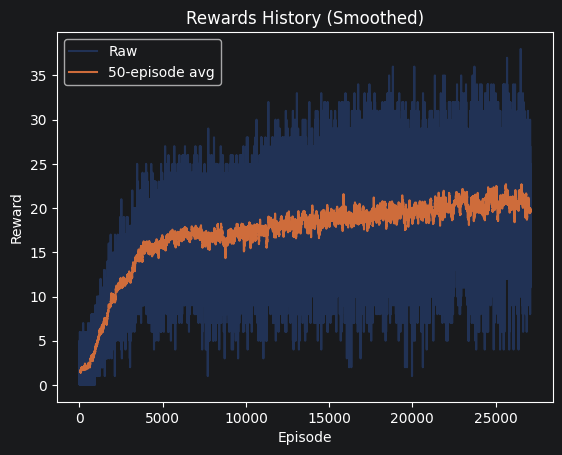

In [14]:
df = pd.read_csv(log_path, skiprows=1)
rewards = df["r"]

plot_reward(rewards)

In [15]:
model_name = "ppo-Breakout"
model.save(model_name)
# model = PPO.load(model_name)

In [16]:
render_callback_atari(model, env_id)

error: video system not initialized